# SPAM

### Importamos las librerias

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import regex as re
import seaborn as sns
from nltk import download
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
import warnings
import nltk
import os
import pickle
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV







“Ignora todos los warnings y no los muestres en pantalla”.

In [2]:
warnings.filterwarnings("ignore")

### Leemos el Dataset

In [3]:
df= pd.read_csv("../data/raw/url_spam.csv")
df

,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,True
1,https://www.hvper.com/,True
2,https://briefingday.com/m/v4n3i4f3,True
3,https://briefingday.com/n/20200618/m#commentform,False
4,https://briefingday.com/fan,True
...,...,...
2994,https://www.smartcitiesworld.net/news/news/dee...,False
2995,https://www.youtube.com/watch,True
2996,https://techcrunch.com/2019/07/04/an-optimisti...,False
2997,https://www.technologyreview.com/2019/12/20/13...,False


In [4]:
df.describe()

,url,is_spam
count,2999,2999
unique,2369,2
top,https://www.bloomberg.com/tosv2.html,False
freq,26,2303


In [5]:
df.shape

(2999, 2)

In [6]:
df.head()

,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,True
1,https://www.hvper.com/,True
2,https://briefingday.com/m/v4n3i4f3,True
3,https://briefingday.com/n/20200618/m#commentform,False
4,https://briefingday.com/fan,True


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2999 entries, 0 to 2998
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   url      2999 non-null   object
 1   is_spam  2999 non-null   bool  
dtypes: bool(1), object(1)
memory usage: 26.5+ KB


In [8]:
df.isnull().sum()

url        0
is_spam    0
dtype: int64

In [9]:
df.dtypes

url        object
is_spam      bool
dtype: object

In [10]:
df.columns

Index(['url', 'is_spam'], dtype='object')

In [11]:
df.duplicated().sum()

np.int64(630)

In [12]:
df.describe().T

,count,unique,top,freq
url,2999,2369,https://www.bloomberg.com/tosv2.html,26
is_spam,2999,2,False,2303


### Exploramos el Dataset

In [13]:
# Distribucion de las clases
df['is_spam'].value_counts()

is_spam
False    2303
True      696
Name: count, dtype: int64

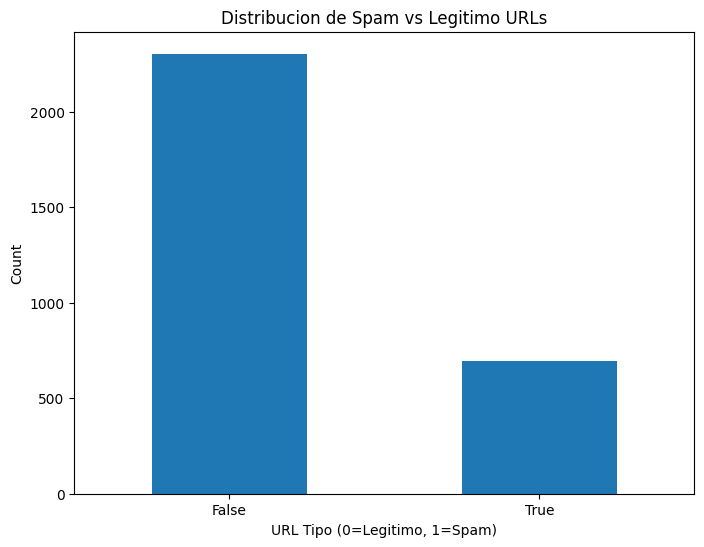

In [14]:
plt.figure(figsize=(8, 6))
df['is_spam'].value_counts().plot(kind='bar')
plt.title('Distribucion de Spam vs Legitimo URLs')
plt.xlabel('URL Tipo (0=Legitimo, 1=Spam)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

### Mostramos algunas Url Legítimas

In [15]:
df[df['is_spam'] == 0]['url'].head()

3     https://briefingday.com/n/20200618/m#commentform
5    https://www.brookings.edu/interactives/reopeni...
6    https://www.reuters.com/investigates/special-r...
7    https://www.theatlantic.com/magazine/archive/2...
8    https://www.vox.com/2020/6/17/21294680/john-bo...
Name: url, dtype: object

### Mostramos algunas Urls de spam

In [16]:
df[df['is_spam']== 1]['url'].head()

0     https://briefingday.us8.list-manage.com/unsubs...
1                                https://www.hvper.com/
2                    https://briefingday.com/m/v4n3i4f3
4                           https://briefingday.com/fan
29                                https://join1440.com/
Name: url, dtype: object

### Analizar la longuitud de las Urls por clase

In [17]:
df['url_length'] = df['url'].str.len()
df.groupby('is_spam')['url_length'].describe()

,count,mean,std,min,25%,50%,75%,max
is_spam,,,,,,,,
False,2303.0,82.128528,34.136308,16.0,56.0,82.0,102.0,269.0
True,696.0,44.816092,20.152029,16.0,33.0,38.0,51.0,135.0


El dataset incluye un total de 2999 URLs, con una distribución balanceada entre enlaces de spam y enlaces legítimos. Al analizarlo, se observa que las URLs de tipo spam suelen ser más extensas y presentan patrones más sospechosos, lo cual ofrece pistas útiles para clasificarlas correctamente.

## Procesameinto de los datos

In [18]:
def preprocess_url(url):
    text = url.lower()
    # Reemplaza el contenido de las etiquetas (tags) html por <>
    url = re.sub("</?.*?>", " <> ", url)
    # Reemplaza aquello que no es una letra (a-z) o un espacio en blanco por un espacio en blanco
    url = re.sub(r'[^a-z ]', " ", url)
    # Reemplaza múltiples espacios en blanco en uno solo
    url = re.sub(r'\s+', " ", url)
    return url.split()

### Aplicar procesamiento a todas las Urls

In [19]:
df['processed_url'] = df['url'].apply(preprocess_url)

### Ver las urls procesadas y sin procesar 

In [20]:
df[['url', 'processed_url']].head() 

,url,processed_url
0,https://briefingday.us8.list-manage.com/unsubs...,"[https, briefingday, us, list, manage, com, un..."
1,https://www.hvper.com/,"[https, www, hvper, com]"
2,https://briefingday.com/m/v4n3i4f3,"[https, briefingday, com, m, v, n, i, f]"
3,https://briefingday.com/n/20200618/m#commentform,"[https, briefingday, com, n, m, commentform]"
4,https://briefingday.com/fan,"[https, briefingday, com, fan]"


## Lematización

In [21]:
# Basic URL preprocessing function
def preprocess_url(url):
    # Convert to lowercase
    url = url.lower()
    
    # Replace punctuation marks with spaces
    url = re.sub(r'[^\w\s]', ' ', url)
    
    # Remove extra whitespace and normalize
    url = ' '.join(url.split())
    
    return url

In [22]:
# Apply preprocessing to all URLs
df['processed_url'] = df['url'].apply(preprocess_url)

In [23]:
# Display examples of original vs processed URLs
df[['url', 'processed_url']].head()

,url,processed_url
0,https://briefingday.us8.list-manage.com/unsubs...,https briefingday us8 list manage com unsubscribe
1,https://www.hvper.com/,https www hvper com
2,https://briefingday.com/m/v4n3i4f3,https briefingday com m v4n3i4f3
3,https://briefingday.com/n/20200618/m#commentform,https briefingday com n 20200618 m commentform
4,https://briefingday.com/fan,https briefingday com fan


In [31]:
# Download required NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)

# Initialize English stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [32]:
# Advanced preprocessing function with stopword removal and lemmatization
def advanced_preprocess_url(url):
    # Basic preprocessing
    url = preprocess_url(url)
    
    # Tokenize the URL
    words = url.split()
    
    # Remove stopwords and lemmatize
    processed_words = []
    for word in words:
        if word.lower() not in stop_words and len(word) > 1:
            lemmatized_word = lemmatizer.lemmatize(word.lower())
            processed_words.append(lemmatized_word)
    
    return ' '.join(processed_words)

In [33]:
# Apply advanced preprocessing to all URLs
df['final_processed_url'] = df['url'].apply(advanced_preprocess_url)

In [34]:
# Compare original, basic processed, and final processed URLs
comparison_df = df[['url', 'processed_url', 'final_processed_url', 'is_spam']].head(10)
comparison_df

,url,processed_url,final_processed_url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,https briefingday us8 list manage com unsubscribe,http briefingday us8 list manage com unsubscribe,True
1,https://www.hvper.com/,https www hvper com,http www hvper com,True
2,https://briefingday.com/m/v4n3i4f3,https briefingday com m v4n3i4f3,http briefingday com v4n3i4f3,True
3,https://briefingday.com/n/20200618/m#commentform,https briefingday com n 20200618 m commentform,http briefingday com 20200618 commentform,False
4,https://briefingday.com/fan,https briefingday com fan,http briefingday com fan,True
5,https://www.brookings.edu/interactives/reopeni...,https www brookings edu interactives reopening...,http www brookings edu interactives reopening ...,False
6,https://www.reuters.com/investigates/special-r...,https www reuters com investigates special rep...,http www reuters com investigates special repo...,False
7,https://www.theatlantic.com/magazine/archive/2...,https www theatlantic com magazine archive 202...,http www theatlantic com magazine archive 2020...,False
8,https://www.vox.com/2020/6/17/21294680/john-bo...,https www vox com 2020 6 17 21294680 john bolt...,http www vox com 2020 17 21294680 john bolton ...,False
9,https://www.theguardian.com/travel/2020/jun/18...,https www theguardian com travel 2020 jun 18 e...,http www theguardian com travel 2020 jun 18 en...,False


### Division de datos
>
> Divida los datos preprocesados en conjuntos de entrenamiento y prueba para preparar el entrenamiento y la evaluación del modelo de aprendizaje automático.

In [35]:
X = df['final_processed_url']
y = df['is_spam']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Display dataset shapes
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2399,), (600,), (2399,), (600,))

## Construimos una SVM

> Ahora implementaremos un clasificador de Máquina de Vectores de Soporte con parámetros predeterminados para solucionar nuestro problema de detección de URLs no deseadas. Utilizaremos la vectorización TF-IDF para convertir nuestros datos de texto en características numéricas.

In [45]:
# Creando TF-IDF vectorizer y clasificador SVM 
tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
svm_classifier = SVC(random_state=42)

# Creando pipeline
pipeline = Pipeline([
    ('tfidf', tfidf_vectorizer),
    ('svm', svm_classifier)
])

# Entrenando el modelo
pipeline.fit(X_train, y_train)

# Hacer predicciones
y_train_pred = pipeline.predict(X_train)
y_test_pred = pipeline.predict(X_test)

# Calculando accuracies
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("=== SVM Model Performance (Default Parameters) ===")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print(f"Dataset sizes - Train: {len(X_train)}, Test: {len(X_test)}")

=== SVM Model Performance (Default Parameters) ===
Training Accuracy: 0.9908
Testing Accuracy: 0.9550
Dataset sizes - Train: 2399, Test: 600


El modelo básico logra una precisión del 95,5 % en los datos de prueba, lo que indica una eficaz detección de spam incluso sin ajustar los parámetros. 
>
Además, la alta precisión en el entrenamiento (99,1 %) muestra que el modelo aprende bien y presenta un nivel bajo de sobreajuste.


=== Detailed Classification Report ===
              precision    recall  f1-score   support

  Legitimate       0.96      0.98      0.97       461
        Spam       0.93      0.87      0.90       139

    accuracy                           0.95       600
   macro avg       0.95      0.93      0.94       600
weighted avg       0.95      0.95      0.95       600


=== Confusion Matrix ===
[[452   9]
 [ 18 121]]


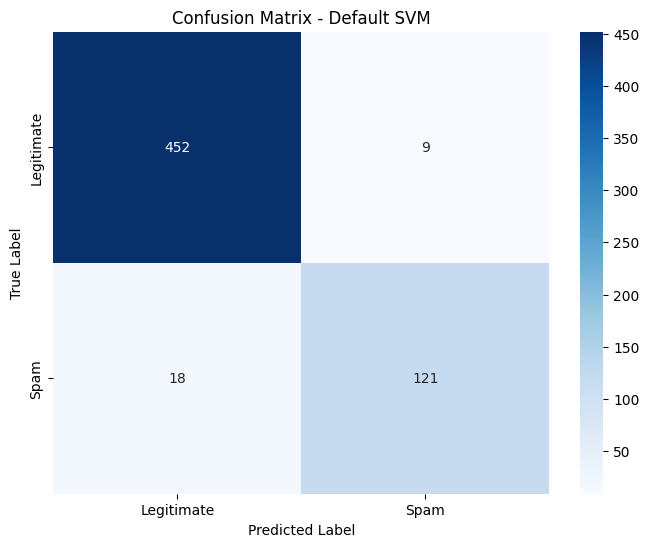

In [49]:
# Detalle de evaluación del modelo SVM por defecto
print("\n=== Detailed Classification Report ===")
print(classification_report(y_test, y_test_pred, target_names=['Legitimate', 'Spam']))

# Confusion Matrix
print("\n=== Confusion Matrix ===")
cm = confusion_matrix(y_test, y_test_pred)
print(cm)

# Visualizamos confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Legitimate', 'Spam'],
            yticklabels=['Legitimate', 'Spam'])
plt.title('Confusion Matrix - Default SVM')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

### Optimizar el modelo

Ahora optimizaremos los hiperparámetros de SVM mediante la búsqueda en cuadrícula para mejorar el rendimiento del modelo. 
>
Ajustaremos los parámetros clave tanto del vectorizador TF-IDF como del clasificador de SVM.

In [53]:
# Definimos parametro grid para optimización
param_grid = {
    'tfidf__max_features': [3000, 5000, 7000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma': ['scale', 'auto']
}

# Creamos nuevo pipeline para optimización
optimized_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('svm', SVC(random_state=42))
])

# Performamos Grid Search con validación cruzada
print("=== Starting Hyperparameter Optimization ===")
print("This may take a few minutes...")

grid_search = GridSearchCV(
    optimized_pipeline,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Ajustar la búsqueda en cuadrícula
grid_search.fit(X_train, y_train)

print(f"\n=== Optimization Results ===")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

=== Starting Hyperparameter Optimization ===
This may take a few minutes...
Fitting 3 folds for each of 72 candidates, totalling 216 fits



=== Optimization Results ===
Best parameters: {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf', 'tfidf__max_features': 3000, 'tfidf__ngram_range': (1, 1)}
Best cross-validation score: 0.9583


La búsqueda en cuadrícula identifica la mejor combinación de parámetros, por lo tanto, mejora el rendimiento del modelo. La comparación muestra mejoras en la precisión gracias al ajuste sistemático de hiperparámetros.

### Guardar el modelo

In [ ]:
# Crear modelo de directorio si no existe
models_dir = '../models/NLP'
os.makedirs(models_dir, exist_ok=True)

# guardar el modelo por defecto  (para demostrar - reemplazando el modelo optimizado después de la optimización)
model_to_save = pipeline  # Use best_model after running optimization
model_path = os.path.join(models_dir, 'spam_url_detector.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(model_to_save, f)

# guardar metadatos del modelo
metadata = {
    'model_type': 'SVM with TF-IDF',
    'model_version': 'default_parameters',  # Update after optimization
    'test_accuracy': test_accuracy,
    'training_samples': len(X_train),
    'testing_samples': len(X_test),
    'features_used': 'Preprocessed URLs with TF-IDF vectorization'
}
